# Computational Efficiency & Inference Latency Benchmark
### SVM vs Random Forest vs CNN (MobileNetV2 Transfer Learning)

This notebook benchmarks all three models across:
- **Training Time** — how long each model takes to train
- **Single-Image Inference Latency** — time to predict one image (ms)
- **Batch Inference Throughput** — frames per second (FPS)
- **Memory Footprint** — RAM used during inference
- **Model Size on Disk** — saved file size
- **Accuracy vs Latency Trade-off** — the core real-time viability metric

**Dataset:** 6-class retail product dataset (blue_boost, tuna_sandwich, purple_boost, quavers, red_boost, pepsi)

## 1. Imports & Configuration

In [1]:
import os
import time
import warnings
import tracemalloc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import joblib
import cv2

from PIL import Image
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
print(f'TensorFlow: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

# ── Dataset paths (update these to match your environment) ───────────────────
TRAIN_PATH = "/Users/theabood/Desktop/DataScience/semester3/Datasets/products/train"
TEST_PATH  = "/Users/theabood/Desktop/DataScience/semester3/Datasets/products/test"

LABEL_MAP = {
    'blue_boost':    0,
    'tuna_sandwhich': 1,
    'purple_boost':  2,
    'quavers':       3,
    'red_boost':     4,
    'pepsi':         5,
}
CLASS_NAMES  = [k for k, _ in sorted(LABEL_MAP.items(), key=lambda x: x[1])]
NUM_CLASSES  = len(LABEL_MAP)
IMG_SIZE_SK  = 64   # SVM / RF use 64×64 flat pixels
IMG_SIZE_CNN = 224  # MobileNetV2 expects 224×224
N_WARMUP     = 5    # warm-up runs before latency timing
N_REPEATS    = 100  # repeated inference runs for stable latency measurement

# Stores final benchmark results for comparison tables & plots
results = {}

/Users/theabood/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow: 2.20.0
GPU available: False


## 2. Data Loading Utilities

In [2]:
def load_flat_data(folder_path, img_size=IMG_SIZE_SK):
    """Load images as flattened float32 vectors — used by SVM & RF."""
    X, y = [], []
    for product, label in LABEL_MAP.items():
        product_path = os.path.join(folder_path, product)
        if not os.path.isdir(product_path):
            print(f'  [WARNING] folder not found: {product_path}')
            continue
        for img_name in os.listdir(product_path):
            if img_name.startswith('.'):
                continue
            img_path = os.path.join(product_path, img_name)
            try:
                img = Image.open(img_path).convert('RGB').resize((img_size, img_size))
                X.append(np.array(img).flatten().astype(np.float32) / 255.0)
                y.append(label)
            except Exception:
                continue
    return np.array(X), np.array(y)


def get_single_flat_image(img_size=IMG_SIZE_SK):
    """Grab the first available test image as a flat vector for latency probing."""
    for product in LABEL_MAP:
        p = os.path.join(TEST_PATH, product)
        if os.path.isdir(p):
            for f in os.listdir(p):
                if not f.startswith('.'):
                    img = Image.open(os.path.join(p, f)).convert('RGB').resize((img_size, img_size))
                    return np.array(img).flatten().astype(np.float32).reshape(1, -1) / 255.0


def get_single_cnn_image():
    """Grab the first available test image pre-processed for MobileNetV2."""
    for product in LABEL_MAP:
        p = os.path.join(TEST_PATH, product)
        if os.path.isdir(p):
            for f in os.listdir(p):
                if not f.startswith('.'):
                    from tensorflow.keras.preprocessing.image import load_img, img_to_array
                    img = load_img(os.path.join(p, f), target_size=(IMG_SIZE_CNN, IMG_SIZE_CNN))
                    arr = img_to_array(img)
                    arr = preprocess_input(arr)
                    return np.expand_dims(arr, axis=0)


print('Loading flat data for SVM / RF ...')
X_train_sk, y_train_sk = load_flat_data(TRAIN_PATH)
X_test_sk,  y_test_sk  = load_flat_data(TEST_PATH)
print(f'  Train: {X_train_sk.shape}  |  Test: {X_test_sk.shape}')

single_flat = get_single_flat_image()
single_cnn  = get_single_cnn_image()
print('Single-image probes ready.')

Loading flat data for SVM / RF ...
  Train: (597, 12288)  |  Test: (144, 12288)
Single-image probes ready.


## 3. Helper — Latency & Memory Profiler

In [3]:
def measure_inference_latency(predict_fn, input_data, n_warmup=N_WARMUP, n_repeats=N_REPEATS):
    """
    Measures single-sample inference latency.

    Steps:
      1. Warm-up runs — prime caches, JIT, etc.
      2. Timed runs — high-resolution wall-clock per call.

    Returns:
      mean_ms, std_ms, min_ms, max_ms, p95_ms
    """
    # Warm-up
    for _ in range(n_warmup):
        predict_fn(input_data)

    # Timed runs
    latencies = []
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        predict_fn(input_data)
        t1 = time.perf_counter()
        latencies.append((t1 - t0) * 1000)   # convert to ms

    arr = np.array(latencies)
    return {
        'mean_ms': float(np.mean(arr)),
        'std_ms':  float(np.std(arr)),
        'min_ms':  float(np.min(arr)),
        'max_ms':  float(np.max(arr)),
        'p95_ms':  float(np.percentile(arr, 95)),
        'fps':     float(1000 / np.mean(arr)),
        'all_ms':  arr.tolist(),
    }


def measure_memory_mb(predict_fn, input_data):
    """Peak RAM (MB) consumed during a single inference call."""
    tracemalloc.start()
    predict_fn(input_data)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak / (1024 ** 2)


def measure_batch_fps(predict_fn, input_batch, label=''):
    """Throughput: images per second over a full test batch."""
    t0 = time.perf_counter()
    predict_fn(input_batch)
    t1 = time.perf_counter()
    elapsed = t1 - t0
    fps = len(input_batch) / elapsed
    print(f'  {label} — batch of {len(input_batch)} in {elapsed:.3f}s  →  {fps:.1f} FPS')
    return fps


print('Profiling utilities ready.')

Profiling utilities ready.


## 4. SVM — Train, Save & Benchmark

In [4]:
print('=' * 55)
print('  SUPPORT VECTOR MACHINE  (RBF kernel + PCA-150 + Scaler)')
print('=' * 55)

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=150)),
    ('svm',    SVC(kernel='rbf', C=10, gamma='scale', probability=True))
])

# ── Training time ─────────────────────────────────────────────────────────────
t0 = time.perf_counter()
svm_model.fit(X_train_sk, y_train_sk)
svm_train_time = time.perf_counter() - t0
print(f'\nTraining time : {svm_train_time:.2f} s')

# ── Accuracy ──────────────────────────────────────────────────────────────────
y_pred_svm = svm_model.predict(X_test_sk)
svm_acc    = accuracy_score(y_test_sk, y_pred_svm)
print(f'Test accuracy : {svm_acc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test_sk, y_pred_svm, target_names=CLASS_NAMES))

# ── Single-image latency ──────────────────────────────────────────────────────
print('Measuring single-image inference latency ...')
svm_lat = measure_inference_latency(svm_model.predict, single_flat)
print(f'  Mean latency : {svm_lat["mean_ms"]:.3f} ms  (±{svm_lat["std_ms"]:.3f})')
print(f'  P95  latency : {svm_lat["p95_ms"]:.3f} ms')
print(f'  Throughput   : {svm_lat["fps"]:.1f} FPS  (single-image loop)')

# ── Batch throughput ──────────────────────────────────────────────────────────
print('Measuring batch throughput ...')
svm_fps_batch = measure_batch_fps(svm_model.predict, X_test_sk, label='SVM')

# ── Memory ───────────────────────────────────────────────────────────────────
svm_mem_mb = measure_memory_mb(svm_model.predict, single_flat)
print(f'  Peak RAM (inference) : {svm_mem_mb:.2f} MB')

# ── Model size ────────────────────────────────────────────────────────────────
svm_path = '/tmp/svm_model.pkl'
joblib.dump(svm_model, svm_path)
svm_size_mb = os.path.getsize(svm_path) / (1024 ** 2)
print(f'  Model size on disk   : {svm_size_mb:.2f} MB')

results['SVM'] = {
    'train_time_s':  svm_train_time,
    'accuracy':      svm_acc,
    'latency_mean_ms': svm_lat['mean_ms'],
    'latency_p95_ms':  svm_lat['p95_ms'],
    'fps_single':    svm_lat['fps'],
    'fps_batch':     svm_fps_batch,
    'memory_mb':     svm_mem_mb,
    'model_size_mb': svm_size_mb,
    'latency_all':   svm_lat['all_ms'],
}

  SUPPORT VECTOR MACHINE  (RBF kernel + PCA-150 + Scaler)

Training time : 5.64 s
Test accuracy : 0.8542

Classification Report:
                precision    recall  f1-score   support

    blue_boost       0.86      1.00      0.92        24
tuna_sandwhich       1.00      0.96      0.98        24
  purple_boost       0.62      0.54      0.58        24
       quavers       0.96      1.00      0.98        24
     red_boost       0.83      0.83      0.83        24
         pepsi       0.83      0.79      0.81        24

      accuracy                           0.85       144
     macro avg       0.85      0.85      0.85       144
  weighted avg       0.85      0.85      0.85       144

Measuring single-image inference latency ...
  Mean latency : 2.569 ms  (±0.922)
  P95  latency : 4.822 ms
  Throughput   : 389.3 FPS  (single-image loop)
Measuring batch throughput ...
  SVM — batch of 144 in 0.041s  →  3503.4 FPS
  Peak RAM (inference) : 0.17 MB
  Model size on disk   : 8.04 MB


## 5. Random Forest — Train, Save & Benchmark

In [5]:
print('=' * 55)
print('  RANDOM FOREST  (n_estimators=100)')
print('=' * 55)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1           # use all CPU cores
)

# ── Training time ─────────────────────────────────────────────────────────────
t0 = time.perf_counter()
rf_model.fit(X_train_sk, y_train_sk)
rf_train_time = time.perf_counter() - t0
print(f'\nTraining time : {rf_train_time:.2f} s')

# ── Accuracy ──────────────────────────────────────────────────────────────────
y_pred_rf = rf_model.predict(X_test_sk)
rf_acc    = accuracy_score(y_test_sk, y_pred_rf)
print(f'Test accuracy : {rf_acc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test_sk, y_pred_rf, target_names=CLASS_NAMES))

# ── Single-image latency ──────────────────────────────────────────────────────
print('Measuring single-image inference latency ...')
rf_lat = measure_inference_latency(rf_model.predict, single_flat)
print(f'  Mean latency : {rf_lat["mean_ms"]:.3f} ms  (±{rf_lat["std_ms"]:.3f})')
print(f'  P95  latency : {rf_lat["p95_ms"]:.3f} ms')
print(f'  Throughput   : {rf_lat["fps"]:.1f} FPS  (single-image loop)')

# ── Batch throughput ──────────────────────────────────────────────────────────
print('Measuring batch throughput ...')
rf_fps_batch = measure_batch_fps(rf_model.predict, X_test_sk, label='RF')

# ── Memory ───────────────────────────────────────────────────────────────────
rf_mem_mb = measure_memory_mb(rf_model.predict, single_flat)
print(f'  Peak RAM (inference) : {rf_mem_mb:.2f} MB')

# ── Model size ────────────────────────────────────────────────────────────────
rf_path = '/tmp/rf_model.pkl'
joblib.dump(rf_model, rf_path)
rf_size_mb = os.path.getsize(rf_path) / (1024 ** 2)
print(f'  Model size on disk   : {rf_size_mb:.2f} MB')

results['RF'] = {
    'train_time_s':    rf_train_time,
    'accuracy':        rf_acc,
    'latency_mean_ms': rf_lat['mean_ms'],
    'latency_p95_ms':  rf_lat['p95_ms'],
    'fps_single':      rf_lat['fps'],
    'fps_batch':       rf_fps_batch,
    'memory_mb':       rf_mem_mb,
    'model_size_mb':   rf_size_mb,
    'latency_all':     rf_lat['all_ms'],
}

  RANDOM FOREST  (n_estimators=100)

Training time : 2.50 s
Test accuracy : 0.8403

Classification Report:
                precision    recall  f1-score   support

    blue_boost       0.86      1.00      0.92        24
tuna_sandwhich       1.00      0.83      0.91        24
  purple_boost       0.67      0.58      0.62        24
       quavers       0.89      1.00      0.94        24
     red_boost       0.80      0.83      0.82        24
         pepsi       0.83      0.79      0.81        24

      accuracy                           0.84       144
     macro avg       0.84      0.84      0.84       144
  weighted avg       0.84      0.84      0.84       144

Measuring single-image inference latency ...
  Mean latency : 27.838 ms  (±15.258)
  P95  latency : 60.232 ms
  Throughput   : 35.9 FPS  (single-image loop)
Measuring batch throughput ...
  RF — batch of 144 in 0.032s  →  4521.7 FPS
  Peak RAM (inference) : 0.12 MB
  Model size on disk   : 1.77 MB


## 6. CNN — MobileNetV2 Transfer Learning — Train & Benchmark

In [6]:
print('=' * 55)
print('  CNN — MobileNetV2 Transfer Learning')
print('=' * 55)

BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    brightness_range=[0.3, 1.0],
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

training_set = train_datagen.flow_from_directory(
    TRAIN_PATH, target_size=(IMG_SIZE_CNN, IMG_SIZE_CNN),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
test_set = test_datagen.flow_from_directory(
    TEST_PATH, target_size=(IMG_SIZE_CNN, IMG_SIZE_CNN),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# ── Build model ───────────────────────────────────────────────────────────────
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x      = base_model.output
x      = GlobalAveragePooling2D()(x)
x      = Dense(256, activation='relu')(x)
x      = BatchNormalization()(x)
x      = Dropout(0.5)(x)
x      = Dense(128, activation='relu')(x)
x      = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

cnn_model = Model(inputs=base_model.input, outputs=output)
cnn_model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

print(f'Total params     : {cnn_model.count_params():,}')
print(f'Trainable params : {sum(np.prod(v.shape) for v in cnn_model.trainable_weights):,}')

# ── Phase 1 training ──────────────────────────────────────────────────────────
early_stop1 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
print('\n=== Phase 1: training head only ===')
t0 = time.perf_counter()
history1 = cnn_model.fit(training_set, epochs=10, validation_data=test_set, callbacks=[early_stop1])
phase1_time = time.perf_counter() - t0

# ── Phase 2 fine-tuning ───────────────────────────────────────────────────────
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
cnn_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

early_stop2 = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr   = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=0)
print('\n=== Phase 2: fine-tuning top layers ===')
t1 = time.perf_counter()
history2 = cnn_model.fit(training_set, epochs=30, validation_data=test_set,
                          callbacks=[early_stop2, reduce_lr])
cnn_train_time = (time.perf_counter() - t1) + phase1_time
print(f'\nTotal training time : {cnn_train_time:.2f} s')

# ── Accuracy ──────────────────────────────────────────────────────────────────
test_set.reset()
true_labels     = test_set.classes
pred_probs      = cnn_model.predict(test_set, verbose=0)
pred_labels     = np.argmax(pred_probs, axis=1)
cnn_acc         = accuracy_score(true_labels, pred_labels)
print(f'Test accuracy : {cnn_acc:.4f}')
print(classification_report(true_labels, pred_labels, target_names=list(test_set.class_indices.keys())))

  CNN — MobileNetV2 Transfer Learning
Found 597 images belonging to 6 classes.
Found 144 images belonging to 6 classes.
Total params     : 2,620,614
Trainable params : 362,118

=== Phase 1: training head only ===
Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.5239 - loss: 1.5451 - val_accuracy: 0.8958 - val_loss: 0.2905
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.9179 - loss: 0.3012 - val_accuracy: 0.9514 - val_loss: 0.1257
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.9681 - loss: 0.1205 - val_accuracy: 0.9861 - val_loss: 0.0666
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.9710 - loss: 0.0827 - val_accuracy: 0.9931 - val_loss: 0.0367
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.9932 - loss: 0.0465 - val_accuracy: 0.9931 - val_loss: 0.0179
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step - accuracy: 0.9818 - loss: 0.0498 - val_accuracy: 0.9861 - val_loss: 0.0376
Epoch 7/10
38/38 ━━━━━━━━━━━━━

In [8]:
# ── Single-image latency ──────────────────────────────────────────────────────
# Use a TF function for fair inference timing (mirrors real deployment)
@tf.function
def cnn_predict_fn(x):
    return cnn_model(x, training=False)

def cnn_predict_numpy(x):
    return cnn_predict_fn(x).numpy()

print('Measuring CNN single-image inference latency ...')
cnn_lat = measure_inference_latency(cnn_predict_numpy, single_cnn)
print(f'  Mean latency : {cnn_lat["mean_ms"]:.3f} ms  (±{cnn_lat["std_ms"]:.3f})')
print(f'  P95  latency : {cnn_lat["p95_ms"]:.3f} ms')
print(f'  Throughput   : {cnn_lat["fps"]:.1f} FPS  (single-image loop)')

# ── Batch throughput  ─────────────────────────────────────────────────────────
# Build a numpy batch from the test generator
test_set.reset()
cnn_batch_X = np.concatenate([test_set[i][0] for i in range(len(test_set))], axis=0)
print(f'CNN batch shape: {cnn_batch_X.shape}')

t0 = time.perf_counter()
cnn_model.predict(cnn_batch_X, batch_size=16, verbose=0)
t1 = time.perf_counter()
cnn_fps_batch = len(cnn_batch_X) / (t1 - t0)
print(f'  CNN batch FPS : {cnn_fps_batch:.1f}')

# ── Memory ────────────────────────────────────────────────────────────────────
cnn_mem_mb = measure_memory_mb(cnn_predict_numpy, single_cnn)
print(f'  Peak RAM (inference) : {cnn_mem_mb:.2f} MB')

# ── Model size ────────────────────────────────────────────────────────────────
cnn_save_path = '/tmp/cnn_mobilenetv2.keras'     # .keras extension required by Keras 3
cnn_model.save(cnn_save_path)
cnn_size_mb = os.path.getsize(cnn_save_path) / (1024 ** 2)  # single file now
print(f'  Model size on disk : {cnn_size_mb:.2f} MB')

results['CNN (MobileNetV2)'] = {
    'train_time_s':    cnn_train_time,
    'accuracy':        cnn_acc,
    'latency_mean_ms': cnn_lat['mean_ms'],
    'latency_p95_ms':  cnn_lat['p95_ms'],
    'fps_single':      cnn_lat['fps'],
    'fps_batch':       cnn_fps_batch,
    'memory_mb':       cnn_mem_mb,
    'model_size_mb':   cnn_size_mb,
    'latency_all':     cnn_lat['all_ms'],
}

Measuring CNN single-image inference latency ...
  Mean latency : 36.508 ms  (±6.818)
  P95  latency : 48.999 ms
  Throughput   : 27.4 FPS  (single-image loop)
CNN batch shape: (144, 224, 224, 3)
  CNN batch FPS : 44.4
  Peak RAM (inference) : 0.59 MB
  Model size on disk : 25.00 MB


## 7. Results Summary Table

In [9]:
df = pd.DataFrame(results).T
df = df.drop(columns=['latency_all'])   # exclude raw arrays from table
df = df.rename(columns={
    'train_time_s':    'Train Time (s)',
    'accuracy':        'Accuracy',
    'latency_mean_ms': 'Latency Mean (ms)',
    'latency_p95_ms':  'Latency P95 (ms)',
    'fps_single':      'FPS (single-img)',
    'fps_batch':       'FPS (batch)',
    'memory_mb':       'Peak RAM (MB)',
    'model_size_mb':   'Model Size (MB)',
})

# Format nicely
fmt = {
    'Train Time (s)':    '{:.2f}',
    'Accuracy':          '{:.4f}',
    'Latency Mean (ms)': '{:.3f}',
    'Latency P95 (ms)':  '{:.3f}',
    'FPS (single-img)':  '{:.1f}',
    'FPS (batch)':       '{:.1f}',
    'Peak RAM (MB)':     '{:.2f}',
    'Model Size (MB)':   '{:.2f}',
}
print('\n=== BENCHMARK RESULTS ===')
print(df.to_string(float_format=lambda x: f'{x:.3f}'))


=== BENCHMARK RESULTS ===
                  Train Time (s) Accuracy Latency Mean (ms) Latency P95 (ms) FPS (single-img) FPS (batch) Peak RAM (MB) Model Size (MB)
SVM                        5.637    0.854             2.569            4.822          389.299    3503.426         0.174           8.037
RF                         2.502    0.840            27.838           60.232           35.922    4521.737         0.119           1.771
CNN (MobileNetV2)       2942.461    1.000            36.508           48.999           27.391      44.382         0.591          25.001


## 8. Visualisations

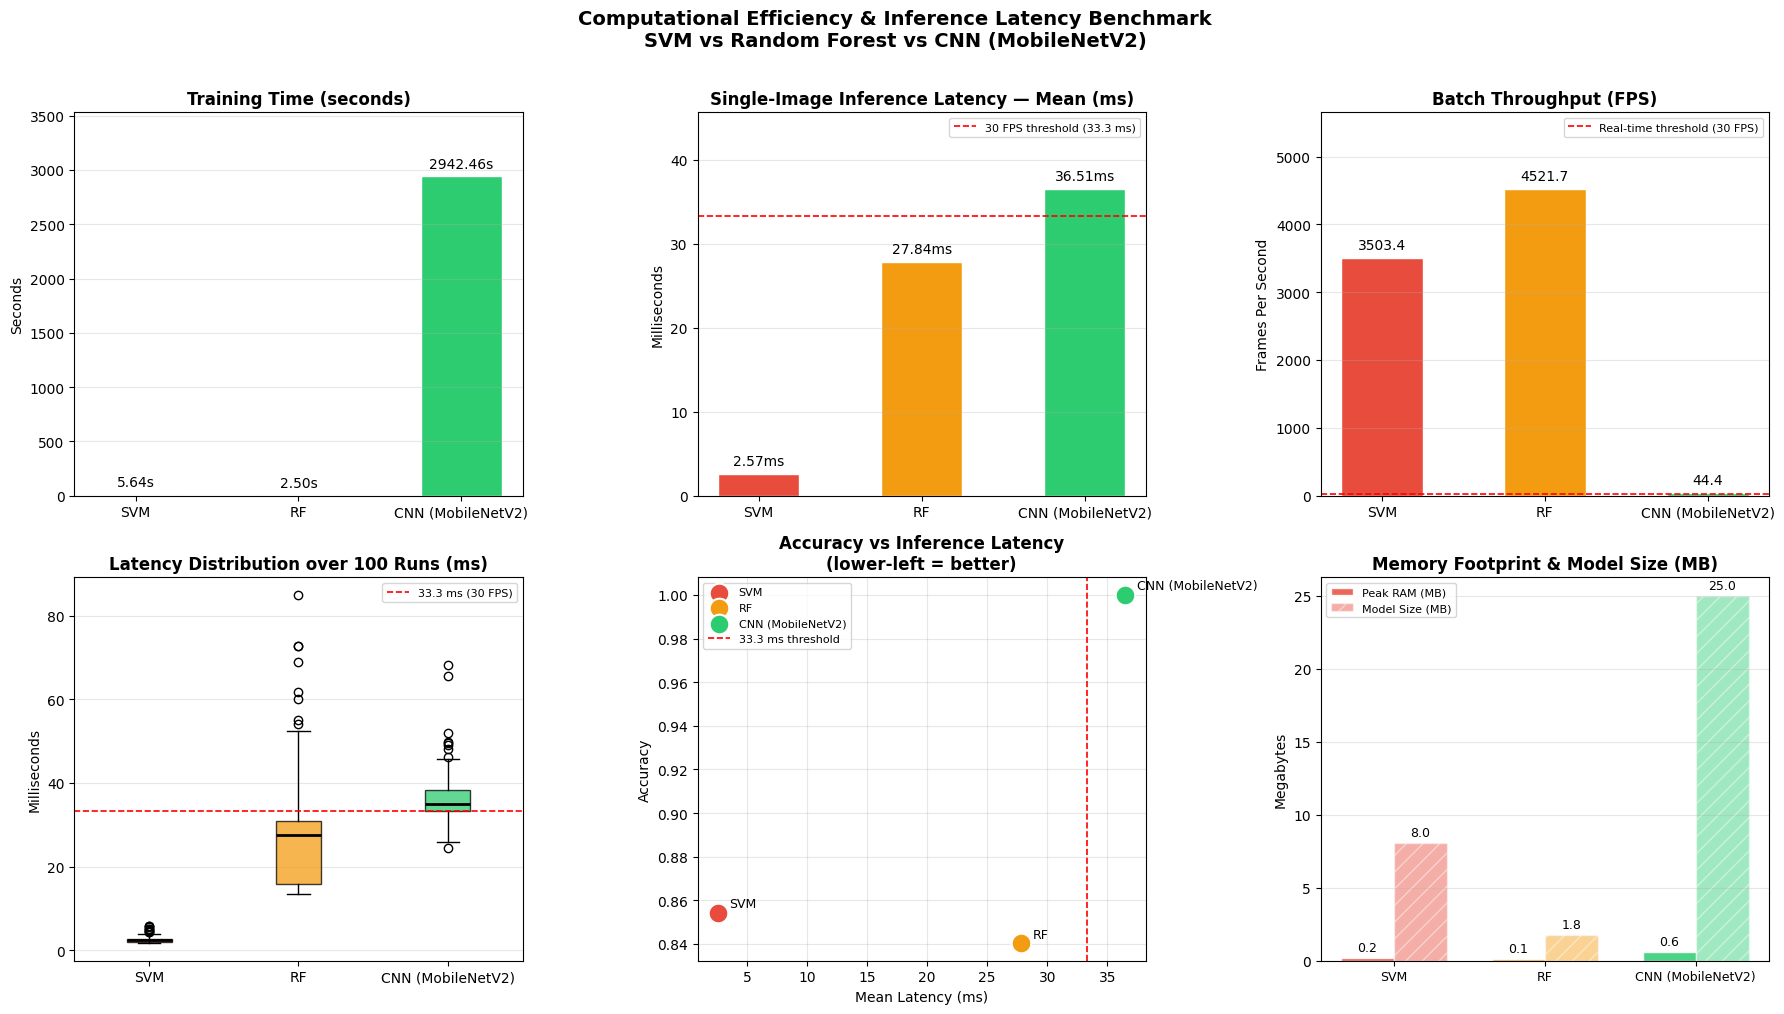

Figure saved to /tmp/benchmark_results.png


In [10]:
COLORS = {'SVM': '#E74C3C', 'RF': '#F39C12', 'CNN (MobileNetV2)': '#2ECC71'}
models = list(results.keys())
colors = [COLORS[m] for m in models]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Computational Efficiency & Inference Latency Benchmark\nSVM vs Random Forest vs CNN (MobileNetV2)',
             fontsize=14, fontweight='bold', y=1.01)

# ── Plot 1: Training Time ─────────────────────────────────────────────────────
ax = axes[0, 0]
vals = [results[m]['train_time_s'] for m in models]
bars = ax.bar(models, vals, color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, labels=[f'{v:.2f}s' for v in vals], padding=4, fontsize=10)
ax.set_title('Training Time (seconds)', fontweight='bold')
ax.set_ylabel('Seconds')
ax.set_ylim(0, max(vals) * 1.2)
ax.grid(axis='y', alpha=0.3)

# ── Plot 2: Single-image Latency (mean) ───────────────────────────────────────
ax = axes[0, 1]
vals = [results[m]['latency_mean_ms'] for m in models]
bars = ax.bar(models, vals, color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, labels=[f'{v:.2f}ms' for v in vals], padding=4, fontsize=10)
ax.axhline(y=33.3, color='red', linestyle='--', linewidth=1.2, label='30 FPS threshold (33.3 ms)')
ax.set_title('Single-Image Inference Latency — Mean (ms)', fontweight='bold')
ax.set_ylabel('Milliseconds')
ax.set_ylim(0, max(vals) * 1.25)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Plot 3: FPS — Batch Throughput ────────────────────────────────────────────
ax = axes[0, 2]
vals = [results[m]['fps_batch'] for m in models]
bars = ax.bar(models, vals, color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, labels=[f'{v:.1f}' for v in vals], padding=4, fontsize=10)
ax.axhline(y=30, color='red', linestyle='--', linewidth=1.2, label='Real-time threshold (30 FPS)')
ax.set_title('Batch Throughput (FPS)', fontweight='bold')
ax.set_ylabel('Frames Per Second')
ax.set_ylim(0, max(vals) * 1.25)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Plot 4: Latency Distribution (box plot) ───────────────────────────────────
ax = axes[1, 0]
lat_data = [results[m]['latency_all'] for m in models]
bp = ax.boxplot(lat_data, labels=models, patch_artist=True, notch=False,
                medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.axhline(y=33.3, color='red', linestyle='--', linewidth=1.2, label='33.3 ms (30 FPS)')
ax.set_title('Latency Distribution over 100 Runs (ms)', fontweight='bold')
ax.set_ylabel('Milliseconds')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Plot 5: Accuracy vs Mean Latency scatter ──────────────────────────────────
ax = axes[1, 1]
for m, c in zip(models, colors):
    ax.scatter(
        results[m]['latency_mean_ms'],
        results[m]['accuracy'],
        color=c, s=200, zorder=5, edgecolors='white', linewidths=1.5, label=m
    )
    ax.annotate(
        m,
        (results[m]['latency_mean_ms'], results[m]['accuracy']),
        textcoords='offset points', xytext=(8, 4), fontsize=9
    )
ax.axvline(x=33.3, color='red', linestyle='--', linewidth=1.2, label='33.3 ms threshold')
ax.set_title('Accuracy vs Inference Latency\n(lower-left = better)', fontweight='bold')
ax.set_xlabel('Mean Latency (ms)')
ax.set_ylabel('Accuracy')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Plot 6: Peak RAM & Model Size ─────────────────────────────────────────────
ax = axes[1, 2]
x_pos  = np.arange(len(models))
width  = 0.35
ram_v  = [results[m]['memory_mb']     for m in models]
size_v = [results[m]['model_size_mb'] for m in models]
b1 = ax.bar(x_pos - width/2, ram_v,  width, label='Peak RAM (MB)',     color=colors, alpha=0.85, edgecolor='white')
b2 = ax.bar(x_pos + width/2, size_v, width, label='Model Size (MB)',   color=colors, alpha=0.45, edgecolor='white', hatch='//')
ax.bar_label(b1, labels=[f'{v:.1f}' for v in ram_v],  padding=3, fontsize=9)
ax.bar_label(b2, labels=[f'{v:.1f}' for v in size_v], padding=3, fontsize=9)
ax.set_xticks(x_pos)
ax.set_xticklabels(models, fontsize=9)
ax.set_title('Memory Footprint & Model Size (MB)', fontweight='bold')
ax.set_ylabel('Megabytes')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to /tmp/benchmark_results.png')

## 9. Latency Percentile Profile (P50 / P75 / P90 / P95 / P99)

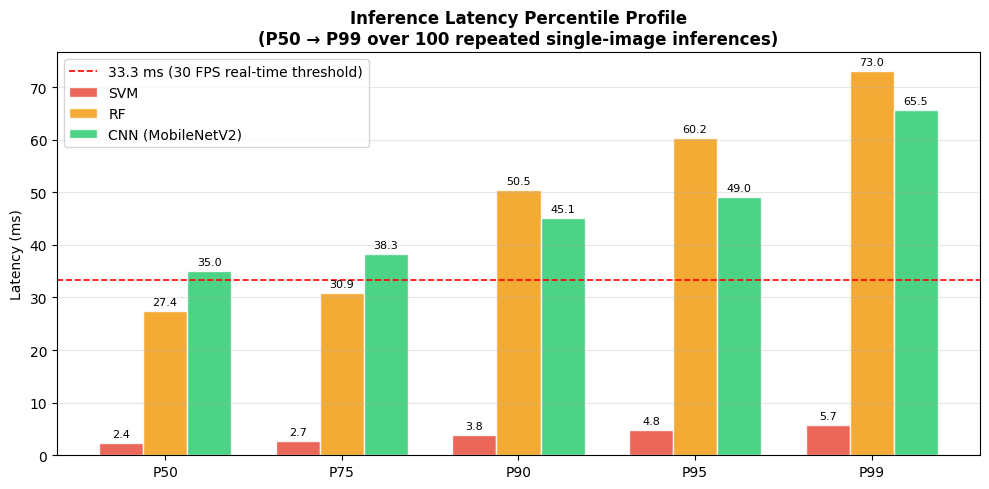


Percentile Table (ms):
                     P50    P75    P90    P95    P99
SVM                2.351  2.710  3.825  4.822  5.723
RF                27.436 30.897 50.467 60.232 72.980
CNN (MobileNetV2) 35.023 38.313 45.115 48.999 65.536


In [11]:
percentiles = [50, 75, 90, 95, 99]
perc_data   = {}

for m in models:
    arr = np.array(results[m]['latency_all'])
    perc_data[m] = [np.percentile(arr, p) for p in percentiles]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(percentiles))
width = 0.25
offsets = [-width, 0, width]

for i, (m, c) in enumerate(zip(models, colors)):
    bars = ax.bar(x + offsets[i], perc_data[m], width, label=m, color=c,
                  alpha=0.85, edgecolor='white')
    ax.bar_label(bars, labels=[f'{v:.1f}' for v in perc_data[m]],
                 padding=3, fontsize=8)

ax.axhline(y=33.3, color='red', linestyle='--', linewidth=1.2, label='33.3 ms (30 FPS real-time threshold)')
ax.set_xticks(x)
ax.set_xticklabels([f'P{p}' for p in percentiles])
ax.set_title('Inference Latency Percentile Profile\n(P50 → P99 over 100 repeated single-image inferences)',
             fontweight='bold')
ax.set_ylabel('Latency (ms)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/latency_percentiles.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPercentile Table (ms):')
perc_df = pd.DataFrame(perc_data, index=[f'P{p}' for p in percentiles]).T
print(perc_df.to_string(float_format='{:.3f}'.format))

## 10. Final Interpretation

The cells below print a structured plain-English interpretation of every benchmark dimension — ready to paste into a report.

In [12]:
REALTIME_THRESHOLD_MS = 33.3  # 30 FPS

print('=' * 65)
print('  COMPUTATIONAL EFFICIENCY & INFERENCE LATENCY — INTERPRETATION')
print('=' * 65)

for m in models:
    r = results[m]
    rt_ok = '✅ MEETS' if r['latency_mean_ms'] < REALTIME_THRESHOLD_MS else '❌ FAILS'
    print(f"\n{'─'*55}")
    print(f"  {m}")
    print(f"{'─'*55}")
    print(f"  Training time        : {r['train_time_s']:.2f} s")
    print(f"  Test accuracy        : {r['accuracy']:.4f}  ({r['accuracy']*100:.2f}%)")
    print(f"  Mean latency         : {r['latency_mean_ms']:.3f} ms")
    print(f"  P95 latency          : {r['latency_p95_ms']:.3f} ms")
    print(f"  FPS (single-img)     : {r['fps_single']:.1f}")
    print(f"  FPS (batch)          : {r['fps_batch']:.1f}")
    print(f"  Peak RAM             : {r['memory_mb']:.2f} MB")
    print(f"  Model size on disk   : {r['model_size_mb']:.2f} MB")
    print(f"  Real-time viability  : {rt_ok} 30 FPS threshold")

print(f"\n{'=' * 65}")
print('  SUMMARY')
print(f"{'=' * 65}")

best_lat = min(models, key=lambda m: results[m]['latency_mean_ms'])
best_acc = max(models, key=lambda m: results[m]['accuracy'])
best_fps = max(models, key=lambda m: results[m]['fps_batch'])

print(f"  Lowest latency  : {best_lat}  ({results[best_lat]['latency_mean_ms']:.3f} ms)")
print(f"  Highest accuracy: {best_acc}  ({results[best_acc]['accuracy']*100:.2f}%)")
print(f"  Highest FPS     : {best_fps}  ({results[best_fps]['fps_batch']:.1f} FPS)")
print()

for m in models:
    r = results[m]
    if r['latency_mean_ms'] < REALTIME_THRESHOLD_MS:
        verdict = f"{m} achieves {r['latency_mean_ms']:.2f} ms mean latency → viable for real-time checkout."
    else:
        excess = r['latency_mean_ms'] - REALTIME_THRESHOLD_MS
        verdict = (f"{m} exceeds the 33.3 ms threshold by {excess:.2f} ms → "
                   f"NOT suitable for real-time single-frame checkout scanning.")
    print(f"  {verdict}")

  COMPUTATIONAL EFFICIENCY & INFERENCE LATENCY — INTERPRETATION

───────────────────────────────────────────────────────
  SVM
───────────────────────────────────────────────────────
  Training time        : 5.64 s
  Test accuracy        : 0.8542  (85.42%)
  Mean latency         : 2.569 ms
  P95 latency          : 4.822 ms
  FPS (single-img)     : 389.3
  FPS (batch)          : 3503.4
  Peak RAM             : 0.17 MB
  Model size on disk   : 8.04 MB
  Real-time viability  : ✅ MEETS 30 FPS threshold

───────────────────────────────────────────────────────
  RF
───────────────────────────────────────────────────────
  Training time        : 2.50 s
  Test accuracy        : 0.8403  (84.03%)
  Mean latency         : 27.838 ms
  P95 latency          : 60.232 ms
  FPS (single-img)     : 35.9
  FPS (batch)          : 4521.7
  Peak RAM             : 0.12 MB
  Model size on disk   : 1.77 MB
  Real-time viability  : ✅ MEETS 30 FPS threshold

───────────────────────────────────────────────────────